# Google Meridian MMM Case Study
Candidate: Ulyana Luzhkova
Role: Junior Data Analyst / Analytics Engineer

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/MMM_data.xlsx")
df = df.rename(columns={
    'DEMAND ': 'DEMAND',
    'GRP(Radio': 'GRP(Radio)'
})

df.head()

,TV Manufacturing Brand,DATE,DEMAND,Consumer Price Index (CPI),Consumer Confidence Index(CCI),Producer Price Index (PPI),Unit Price ($),POS/ Supply Data,SALES ($),Advertising Expenses (SMS),Advertising Expenses(Newspaper ads),Advertising Expenses(Radio),Advertising Expenses(TV),Advertising Expenses(Internet),GRP (NewPaper ads),GRP(SMS),GRP(Radio),GRP(Internet),GRP(TV)
0,TV Manufacturing & Supplier Unit,2010-01-01,4384,104.9,96.3,106.7,361.62,4240,1533268.80,77.4819,14.104193,112.3370,1479.4565,722.571,95.333,11.8398,91.0000,276.3636,756.5909
1,TV Manufacturing & Supplier Unit,2010-01-02,4366,104.9,96.3,106.7,361.62,4266,1542670.92,73.4783,13.298758,105.7133,1369.8913,717.857,114.957,27.8039,111.9091,291.3182,860.1364
2,TV Manufacturing & Supplier Unit,2010-01-03,4006,104.9,96.3,106.7,361.62,4206,1520973.72,80.6093,13.200691,108.7702,1428.0645,653.333,113.090,0.0000,94.6364,282.7273,751.9545
3,TV Manufacturing & Supplier Unit,2010-01-04,4076,104.9,96.3,106.7,361.62,4176,1510125.12,65.9319,12.721429,93.3065,1309.3548,622.095,72.442,0.0000,98.5909,306.3182,749.4545
4,TV Manufacturing & Supplier Unit,2010-01-05,4834,104.9,96.3,106.7,361.62,5234,1892719.08,77.4819,14.104193,112.3370,1479.4565,722.571,95.333,11.8398,91.0000,276.3636,756.5909


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2613 entries, 0 to 2612
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   TV Manufacturing Brand               2613 non-null   object        
 1   DATE                                 2613 non-null   datetime64[ns]
 2   DEMAND                               2613 non-null   int64         
 3   Consumer Price Index (CPI)           2613 non-null   float64       
 4   Consumer Confidence Index(CCI)       2613 non-null   float64       
 5   Producer Price Index (PPI)           2613 non-null   float64       
 6   Unit Price ($)                       2613 non-null   float64       
 7   POS/ Supply Data                     2613 non-null   int64         
 8   SALES ($)                            2613 non-null   float64       
 9   Advertising Expenses (SMS)           2613 non-null   float64       
 10  Advertising 

In [62]:
df.shape

(2613, 19)

In [63]:
print(df.columns.tolist())

['TV Manufacturing Brand', 'DATE', 'DEMAND', 'Consumer Price Index (CPI)', 'Consumer Confidence Index(CCI)', 'Producer Price Index (PPI)', 'Unit Price ($)', 'POS/ Supply Data', 'SALES ($)', 'Advertising Expenses (SMS)', 'Advertising Expenses(Newspaper ads)', 'Advertising Expenses(Radio)', 'Advertising Expenses(TV)', 'Advertising Expenses(Internet)', 'GRP (NewPaper ads)', 'GRP(SMS)', 'GRP(Radio)', 'GRP(Internet)', 'GRP(TV)']


# 1. Weekly Resampling: Агрегируйте ежедневные данные в недельные (с началом в воскресенье). Убедитесь, что Sales и Spend суммируются, а индексы (CPI, CCI) — усредняются.

In [64]:
df['WEEK'] = df ['DATE'].dt.to_period('W-SAT')

weekly = df.groupby('WEEK').agg({
    'TV Manufacturing Brand': 'first',
    
    'DEMAND': 'sum',
    'SALES ($)': 'sum',
    'POS/ Supply Data': 'sum',

    'Advertising Expenses (SMS)': 'sum',
    'Advertising Expenses(Newspaper ads)': 'sum',
    'Advertising Expenses(Radio)': 'sum',
    'Advertising Expenses(TV)': 'sum',
    'Advertising Expenses(Internet)': 'sum',

    'GRP (NewPaper ads)': 'sum',
    'GRP(SMS)': 'sum',
    'GRP(Radio)': 'sum',
    'GRP(Internet)': 'sum',
    'GRP(TV)': 'sum',

    'Consumer Price Index (CPI)': 'mean',
    'Consumer Confidence Index(CCI)': 'mean',
    'Producer Price Index (PPI)': 'mean',
    'Unit Price ($)': 'mean'
}).reset_index()

print(weekly.head())
print(f"Количество недель: {len(weekly)}")


                    WEEK            TV Manufacturing Brand  DEMAND  \
0  2009-12-27/2010-01-02  TV Manufacturing & Supplier Unit    8750   
1  2010-01-03/2010-01-09  TV Manufacturing & Supplier Unit   30309   
2  2010-01-10/2010-01-16  TV Manufacturing & Supplier Unit   36362   
3  2010-01-17/2010-01-23  TV Manufacturing & Supplier Unit   48450   
4  2010-01-24/2010-01-30  TV Manufacturing & Supplier Unit   74249   

     SALES ($)  POS/ Supply Data  Advertising Expenses (SMS)  \
0   3075939.72              8506                    150.9602   
1  11256868.98             31129                    533.7709   
2  13402360.44             37062                    518.1557   
3  18297972.00             50600                    484.6265   
4  26132469.30             72265                    536.7159   

   Advertising Expenses(Newspaper ads)  Advertising Expenses(Radio)  \
0                            27.402951                     218.0503   
1                            93.039505              

# 3. Data Quality Check: Выявите пропуски или аномалии в данных (например, периоды отсутствия стока POS/ Supply Data).


1. Пропущенные значения (weekly):
WEEK                                   0
TV Manufacturing Brand                 0
DEMAND                                 0
SALES ($)                              0
POS/ Supply Data                       0
Advertising Expenses (SMS)             0
Advertising Expenses(Newspaper ads)    0
Advertising Expenses(Radio)            0
Advertising Expenses(TV)               0
Advertising Expenses(Internet)         0
GRP (NewPaper ads)                     0
GRP(SMS)                               0
GRP(Radio)                             0
GRP(Internet)                          0
GRP(TV)                                0
Consumer Price Index (CPI)             0
Consumer Confidence Index(CCI)         0
Producer Price Index (PPI)             0
Unit Price ($)                         0
dtype: int64

Пропущенные значения (daily):
TV Manufacturing Brand                 0
DATE                                   0
DEMAND                                 0
Consumer Price Index

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arrays\datetimelike.py:1306: RuntimeWarning: overflow encountered in scalar multiply
  new_data = np.array([self.freq.base * x for x in new_i8_data])


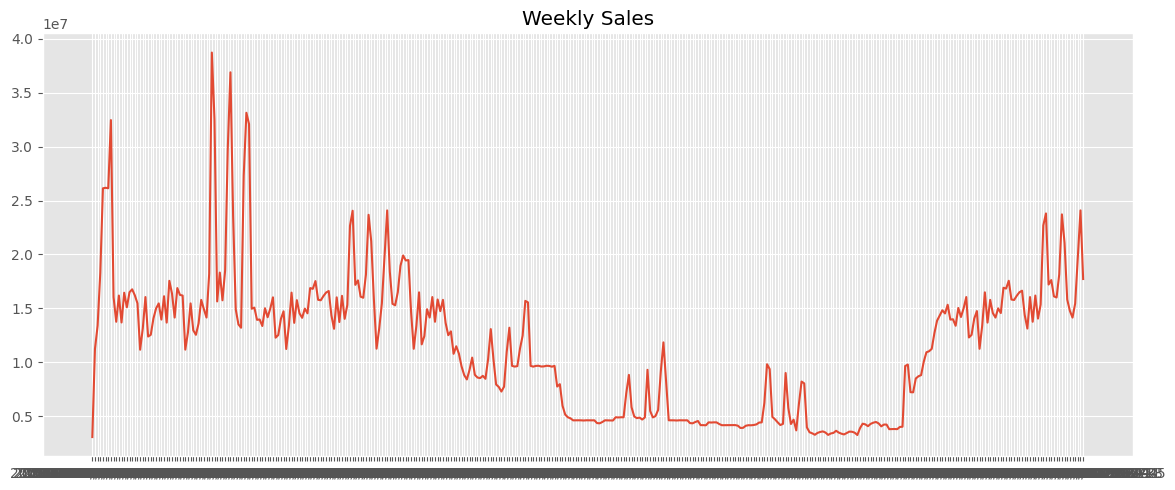

In [65]:
import numpy as np
import matplotlib.pyplot as plt

print("1. Пропущенные значения (weekly):")
print(weekly.isnull().sum())

print("\nПропущенные значения (daily):")
print(df.isnull().sum())

print("\n2. Непрерывность дней (daily):")
daily_diff = df['DATE'].sort_values().diff().value_counts()
print(daily_diff)

print("\n3. Непрерывность недель (weekly):")
weekly_diff = weekly['WEEK'].sort_values().diff().value_counts()
print(weekly_diff)

zero_sales_weekly = (weekly['SALES ($)'] == 0).sum()
zero_sales_daily = (df['SALES ($)'] == 0).sum()
print("\n4. Нулевые продажи:")
print("Недели с нулевыми продажами:", zero_sales_weekly)
print("Дни с нулевыми продажами:", zero_sales_daily)

zero_stock = (df['POS/ Supply Data'] == 0).sum()
print("\n5. Периоды отсутствия стока:", zero_stock)

negative_values = (weekly.select_dtypes(include=[np.number]) < 0).sum()
print("\n6. Отрицательные значения в недельных данных:")
print(negative_values)
print("\nОтрицательные значения в дневных данных:")
print((df.select_dtypes(include=[np.number]) < 0).sum())

print("\n7. Статистика продаж (weekly):")
print(weekly['SALES ($)'].describe())

plt.figure(figsize=(12,5))
plt.plot(weekly['WEEK'].astype(str), weekly['SALES ($)'])
plt.title("Weekly Sales")
plt.tight_layout()
plt.show()

### Data Quality Check: Результаты проверки

#### 1. Пропущенные значения
- **Weekly data**: 0 пропусков во всех колонках 
- **Daily data**: 0 пропусков во всех колонках

#### 2. Непрерывность временного ряда
- **Daily**: все дни идут подряд: 2612 интервалов по 1 дню на 2613 дней 
- **Weekly**: все недели идут подряд: 373 интервала по 1 неделе на 374 недели

#### 3. Нулевые продажи
- **Weekly**: 0 недель с нулевыми продажами 
- **Daily**: 0 дней с нулевыми продажами 

#### 4. Отсутствие стока (POS/Supply Data)
- **Дней с нулевым стоком**: 0 

#### 5. Отрицательные значения
- **Weekly data**: 0 отрицательных значений во всех колонках 

#### 6. Статистика недельных продаж
- **Количество недель**: 374
- **Средние продажи**: 11 468 600 $

- **Минимальные**: 3 075 940 $
  
- **Максимальные**: 38 714 680 $
  
- **Медиана**: 12 350 410 $
  
- **Вывод**: разброс большой, медиана близка к среднему, max в 3 раза выше среднего (высокие пики)

#### 7. Визуальный анализ
На графике недельных продаж наблюдается:
- Сезонность (регулярные пики и спады)
- Растущий тренд к концу периода

### Итоговое заключение
- Нет пропусков
- Непрерывный временной ряд
- Нет периодов отсутствия товара
- Нет отрицательных значений
- Все недели имеют ненулевые затраты и продажи

Дополнительная очистка данных не требуется.

# 2. Tensor Construction: Сформируйте данные в три массива:
# - Media Tensor: Данные по затратам и соответствующим им GRP.
# - Controls Tensor: Макроэкономические показатели и цена товара.
# - Target Vector: Недельный объем продаж.


In [74]:
y = weekly['SALES ($)'].values

control_columns = [
    'Consumer Price Index (CPI)',
    'Consumer Confidence Index(CCI)',
    'Producer Price Index (PPI)',
    'Unit Price ($)'
]

X_controls = weekly[control_columns].values

grp_columns = [
    'GRP(SMS)',
    'GRP (NewPaper ads)',
    'GRP(Radio)',
    'GRP(TV)',
    'GRP(Internet)'
]

spend_columns = [
    'Advertising Expenses (SMS)',
    'Advertising Expenses(Newspaper ads)',
    'Advertising Expenses(Radio)',
    'Advertising Expenses(TV)',
    'Advertising Expenses(Internet)'
]

grp_data = weekly[grp_columns].values
spend_data = weekly[spend_columns].values

X_media = np.stack([grp_data, spend_data], axis=2)

print("Target shape:", y.shape)
print("Controls shape:", X_controls.shape)
print("Media tensor shape:", X_media.shape)

Target shape: (374,)
Controls shape: (374, 4)
Media tensor shape: (374, 5, 2)


# Часть 2: Математика и эконометрика (Statistics)


# 1. Custom Adstock: Напишите функцию геометрического затухания ($A_t = X_t + \alpha \cdot A_{t-1}$). Реализуйте её для канала TV и сравните визуально эффекты при $\alpha = 0.2$ и $\alpha = 0.7$.


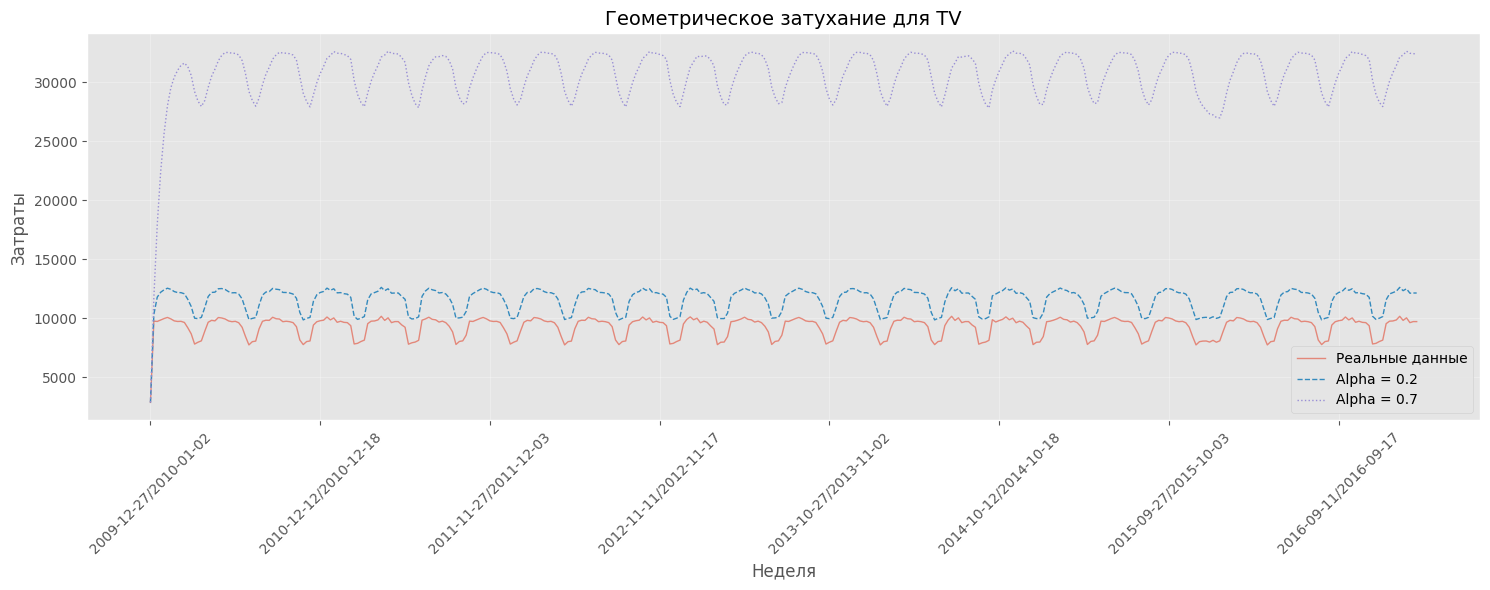

In [75]:
def geometric_adstock(X, alpha):
    n = len(X)
    A = np.zeros(n)
    A[0] = X[0]
    for t in range(1, n):
        A[t] = X[t] + alpha * A[t - 1]
    return A

tv_spend = weekly['Advertising Expenses(TV)'].values

adstok_02 = geometric_adstock(tv_spend, 0.2)
adstok_07 = geometric_adstock(tv_spend, 0.7)

plt.figure(figsize = (15, 6))
weeks_index = np.arange(len(weekly))

plt.plot(weeks_index, tv_spend, label = 'Реальные данные', alpha = 0.6, linewidth = 1)
plt.plot(weeks_index, adstok_02, label = 'Alpha = 0.2', linestyle = '--', linewidth = 1)
plt.plot(weeks_index, adstok_07, label = 'Alpha = 0.7', linestyle = ':', linewidth = 1)

xticks_positions = np.arange(0, len(weekly), 50)
xticks_labels = [str(weekly['WEEK'].iloc[i]) for i in xticks_positions]
plt.xticks(xticks_positions, xticks_labels, rotation=45)

plt.legend()
plt.title('Геометрическое затухание для TV', fontsize = 14)
plt.xlabel('Неделя')
plt.ylabel('Затраты')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()


# 2. Эластичность: Рассчитайте коэффициент эластичности спроса по цене (Unit Price ($)).


In [76]:
price_changes = []
for i in range(1, len(weekly)):
    if weekly['Unit Price ($)'].iloc[i] != weekly['Unit Price ($)'].iloc[i-1]:
        price_changes.append((i-1, i))

print(f"Найдено {len(price_changes)} моментов изменения цены\n")

elasticities = []
for before, after in price_changes:
    p1 = weekly['Unit Price ($)'].iloc[before]
    p2 = weekly['Unit Price ($)'].iloc[after]
    q1 = weekly['DEMAND'].iloc[before]
    q2 = weekly['DEMAND'].iloc[after]
    
    delta_p_percent = (p2 - p1) / p1 * 100
    
    if abs(delta_p_percent) > 1:
        delta_p = delta_p_percent
        delta_q = (q2 - q1) / q1 * 100
        
        e = delta_q / delta_p
        elasticities.append(e)
        
        print(f"Недели {before}-{after}: цена {p1:.2f}→{p2:.2f} ({delta_p:+.1f}%), "
              f"спрос {q1}→{q2} ({delta_q:+.1f}%), эластичность = {e:.3f}")

print(f"\nЗначительных изменений (>1%): {len(elasticities)}")

elasticities = np.array(elasticities)

print("\nСТАТИСТИКА ЭЛАСТИЧНОСТИ")
print(f"Средняя: {elasticities.mean():.3f}")
print(f"Медианная: {np.median(elasticities):.3f}")
print(f"Стандартное отклонение: {elasticities.std():.3f}")
print(f"Минимум: {elasticities.min():.3f}")
print(f"Максимум: {elasticities.max():.3f}")

print("\nВЫВОД")
median_e = np.median(elasticities)
print(f"Медианная эластичность спроса по цене: {median_e:.3f}")

if abs(median_e) < 1:
    print("Спрос НЕэластичен: изменение цены слабо влияет на спрос")
elif abs(median_e) > 1:
    print("Спрос эластичен: изменение цены сильно влияет на спрос")
else:
    print("Единичная эластичность")

Найдено 13 моментов изменения цены

Недели 156-157: цена 361.60→389.10 (+7.6%), спрос 26341→30009 (+13.9%), эластичность = 1.831
Недели 157-158: цена 389.10→400.10 (+2.8%), спрос 30009→24889 (-17.1%), эластичность = -6.035
Недели 227-228: цена 400.10→394.60 (-1.4%), спрос 16549→16757 (+1.3%), эластичность = -0.915
Недели 228-229: цена 394.60→361.62 (-8.4%), спрос 16757→13882 (-17.2%), эластичность = 2.053
Недели 264-265: цена 361.62→304.85 (-15.7%), спрос 16262→15365 (-5.5%), эластичность = 0.351
Недели 265-266: цена 304.85→282.14 (-7.4%), спрос 15365→28786 (+87.3%), эластичность = -11.726
Недели 288-289: цена 282.14→321.23 (+13.9%), спрос 15732→16209 (+3.0%), эластичность = 0.219
Недели 289-290: цена 321.23→350.55 (+9.1%), спрос 16209→15383 (-5.1%), эластичность = -0.558
Недели 305-306: цена 350.55→360.04 (+2.7%), спрос 11573→24896 (+115.1%), эластичность = 42.531

Значительных изменений (>1%): 9

СТАТИСТИКА ЭЛАСТИЧНОСТИ
Средняя: 3.083
Медианная: 0.219
Стандартное отклонение: 14.553
М

# 3. Как использование априорных вероятностей помогает моделировать каналы с низким охватом или коротким периодом активности
Априорные вероятности обеспечивают стабилизирующий эффект, направляя модель к правдоподобным результатам и предотвращая неверные выводы, основанные на ограниченных данных.  Priors можно ставить как материальные и измеримые показатели (ROI, например), а не как абстрактные метрики. Так же можно настраивать стандартное отклонение, в зависимости от силы уверенности в значении параметра (если данные скудные, то можно задать большое стандартное отклонение). Можно использовать mROI priors для регуляризации рекомендаций по оптимизации бюджета, сужая их до уровня исторического распределения бюджета (удобно если исторические значения близки к оптимальным).